In [30]:
# Cargando datos
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

filepath = os.path.join(dirname, filename)
cafe_sales_raw = pd.read_csv(filepath)

/kaggle/input/cafe-sales-dirty-data-for-cleaning-training/dirty_cafe_sales.csv


# Vamos a explorar la tabla

In [3]:
type(cafe_sales_raw)
cafe_sales_raw.shape # Nos arroja que tenemos 1000 filas y 8 columnas
cafe_sales_raw.head(10) # Podemos ver un preview de la tabla con 10 valores

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [4]:
# Revisamos si tenemos duplicados en transaction ID
#cafe_sales_raw["Transaction ID"].duplicated().sum()
# Y hacemos copia para la limpieza
cafe_sales = cafe_sales_raw.copy()
# No hay transacciones duplicadas por lo que podemos hacerlo nuestro indice, ya que es el id
cafe_sales.set_index("Transaction ID", inplace = True)

## Columnas de la tabla:
* Transaction ID
* Item
* Quantity
* Price Per Unit
* Total Spent
* Payment Method
* Location
* Transaction Date

**Ahora vamos a ver que valores tiene cada columna**

In [5]:
# Explorando los datos de las columnas que nos interesan (en este caso no payment method ni location)
# Ya que nuestro analisis es de lo más vendido por meses
items_exist = cafe_sales["Item"].value_counts(dropna=False)
quantity_exist = cafe_sales["Quantity"].value_counts(dropna=False)
total_exist = cafe_sales["Total Spent"].value_counts(dropna=False)
date_exist = cafe_sales["Transaction Date"].value_counts(dropna=False)
price_exist = cafe_sales["Price Per Unit"].value_counts(dropna=False)
print(price_exist)

Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
NaN         179
UNKNOWN     164
Name: count, dtype: int64


## Contenido de las columnas: 
### Item
* Juice       1171  
* Coffee      1165
* Salad       1148
* Cake        1139
* Sandwich    1131
* Smoothie    1096
* Cookie      1092
* Tea         1089
* UNKNOWN      344
* NaN          333
* ERROR        292
___________________________
### Quantity
* 5          2013
* 2          1974
* 4          1863
* 3          1849
* 1          1822
* UNKNOWN     171
* ERROR       170
* NaN         138
_________________________
### Total Spent
* 6.0        979
* 12.0       939
* 3.0        930
* 4.0        923
* 20.0       746
* 15.0       734
* 8.0        677
* 10.0       524
* 2.0        497
* 9.0        479
* 5.0        468
* 16.0       444
* 25.0       259
* 7.5        237
* 1.0        232
* 4.5        225
* 1.5        205
* NaN        173
* UNKNOWN    165
* ERROR      164
________________________
### Transaction Date
* UNKNOWN       159
* NaN           159
* ERROR         142   ... ya no escribí el resto porque en este caso me interesa más limpiarlas para que tengan el formato correcto, son ahora strings y no se acomodan por fecha
________________
### Price Per Unit
* 3.0        2429
* 4.0        2331
* 2.0        1227
* 5.0        1204
* 1.0        1143
* 1.5        1133
* ERROR       190
* NaN         179
* UNKNOWN     164

# Data Cleaning

In [6]:
# Ya que no puedo inferir directamente las fechas y no son una porción significativa las que tienen errores, no las tomare en cuenta para mi analisis
cafe_sales["Transaction Date"] = cafe_sales["Transaction Date"].replace("UNKNOWN", np.nan)
cafe_sales["Transaction Date"] = cafe_sales["Transaction Date"].replace("ERROR", np.nan)
# No usaré los valores nulos ya que la fecha es esencial para mi análisis así que retiraré las filas sin fecha:
cafe_sales = cafe_sales.dropna(subset=["Transaction Date"])
# Paso de verificación
cafe_sales["Transaction Date"]
cafe_sales.shape # Ahora tenemos solo 9540 filas

(9540, 7)

In [7]:
# Necesito la mayor cantidad de valores de items así que veré si se pueden inferir con sus costos
# No me dejo al principio porque los valores de price no son numericos por los errores
# cafe_sales_1[["Item","Price Per Unit"]].groupby("Item").mean()

cafe_sales["Price Per Unit"] = cafe_sales["Price Per Unit"].replace("ERROR", np.nan)
cafe_sales["Price Per Unit"] = cafe_sales["Price Per Unit"].replace("UNKNOWN", np.nan)
# Verificación
cafe_sales[["Item","Price Per Unit"]].groupby("Item").value_counts(dropna=False)
cafe_sales["Price Per Unit"] = pd.to_numeric(cafe_sales["Price Per Unit"], errors="coerce")
cafe_sales["Price Per Unit"].value_counts(dropna=False)

Price Per Unit
3.0    2319
4.0    2219
2.0    1185
5.0    1150
1.0    1088
1.5    1073
NaN     506
Name: count, dtype: int64

### Precios 
* Cake:  3
* Juice: 3
* Coffee: 2
* Cookie: 1
* Salad: 5
* Sandwich: 4
* Smoothie: 4
* Tea: 1.5
* Tenemos: NaN     506
Por lo que veo hay dos precios que se repiten 3 y 4, por lo que esos no los podré inferir,pero los demás sí, para poder recuperar la mayor cantidad de registros, pero antes, vemos si podemos inferir algunso precios con cantidad y total gastado

In [8]:
# Primero todos deben ser numeros
cafe_sales["Quantity"] = cafe_sales["Quantity"].replace("ERROR", np.nan)
cafe_sales["Quantity"] = cafe_sales["Quantity"].replace("UNKNOWN", np.nan)
cafe_sales["Quantity"] = pd.to_numeric(cafe_sales["Quantity"], errors="coerce")

cafe_sales["Total Spent"] = cafe_sales["Total Spent"].replace("ERROR", np.nan)
cafe_sales["Total Spent"] = cafe_sales["Total Spent"].replace("UNKNOWN", np.nan)
cafe_sales["Total Spent"] = pd.to_numeric(cafe_sales["Total Spent"], errors="coerce")

In [9]:
# Ahora calculamos los precios unitarios si el valor es nulo y hay suficiente información
cafe_sales.loc[cafe_sales["Price Per Unit"].isna(),"Price Per Unit"] = (cafe_sales["Total Spent"]/cafe_sales["Quantity"])
cafe_sales["Price Per Unit"].value_counts(dropna=False)
# Aun tenemos 506 NaN por lo que no se pudieron calcular más de los datos que ya se contaban, ahora vamos con los nombre de los items

Price Per Unit
3.0    2435
4.0    2330
2.0    1244
5.0    1214
1.0    1146
1.5    1136
NaN      35
Name: count, dtype: int64

In [20]:
## Primero pasamos todos los ERROR y UNKNOWN en null
cafe_sales["Item"] = cafe_sales["Item"].replace("ERROR", np.nan)
cafe_sales["Item"] = cafe_sales["Item"].replace("UNKNOWN", np.nan)

In [21]:
# Si Item es nulo y Price Per Unit == 1.5 then "Tea"
cafe_sales.loc[(cafe_sales["Item"].isna()) & (cafe_sales["Price Per Unit"] == 1.5),"Item"] = "Tea"

# Si Item es nulo y Price Per Unit == 2 then "Coffee"
cafe_sales.loc[(cafe_sales["Item"].isna()) & (cafe_sales["Price Per Unit"] == 2),"Item"] = "Coffee"

# Si Item es nulo y Price Per Unit == 1 then "Cookie"
cafe_sales.loc[(cafe_sales["Item"].isna()) & (cafe_sales["Price Per Unit"] == 1),"Item"] = "Cookie"

# Si Item es nulo y Price Per Unit == 5 then "Salad"
cafe_sales.loc[(cafe_sales["Item"].isna()) & (cafe_sales["Price Per Unit"] == 5),"Item"] = "Salad"

cafe_sales[["Item","Price Per Unit"]].groupby("Item").value_counts(dropna=False)


Item      Price Per Unit
Cake      3.0               1078
          NaN                  4
Coffee    2.0               1246
Cookie    1.0               1151
Juice     3.0               1123
          NaN                  1
Salad     5.0               1216
Sandwich  4.0               1070
          NaN                  5
Smoothie  4.0               1044
          NaN                  4
Tea       1.5               1142
Name: count, dtype: int64

Ya se ve un poco más limpio, ya que tenemos la mayoria de nuestras columnas de items limpias vamos a solo validar los precios de algunas por si a futuro se requiere

In [22]:
cafe_sales.loc[(cafe_sales["Item"]=="Coffee") & (cafe_sales["Price Per Unit"].isna()),"Price Per Unit"] = 2
cafe_sales.loc[(cafe_sales["Item"]== "Salad") & (cafe_sales["Price Per Unit"].isna()),"Price Per Unit"] = 5
cafe_sales.loc[(cafe_sales["Item"]== "Cookie") & (cafe_sales["Price Per Unit"].isna()),"Price Per Unit"] = 1
cafe_sales.loc[(cafe_sales["Item"] == "Tea") & (cafe_sales["Price Per Unit"].isna()),"Price Per Unit"] = 1.5
cafe_sales[["Item","Price Per Unit"]].groupby("Item").value_counts(dropna=False)

Item      Price Per Unit
Cake      3.0               1078
          NaN                  4
Coffee    2.0               1246
Cookie    1.0               1151
Juice     3.0               1123
          NaN                  1
Salad     5.0               1216
Sandwich  4.0               1070
          NaN                  5
Smoothie  4.0               1044
          NaN                  4
Tea       1.5               1142
Name: count, dtype: int64

In [60]:
#cafe_sales.loc[cafe_sales["Quantity"].isna(),"Quantity"] = (cafe_sales["Total Spent"]/cafe_sales["Price Per Unit"])
#cafe_sales.loc[cafe_sales["Total Spent"].isna(),"Total Spent"] = (cafe_sales["Price Per Unit"]*cafe_sales["Quantity"])

# Data Validation

In [23]:
cafe_sales[cafe_sales["Total Spent"] != (cafe_sales["Price Per Unit"]*cafe_sales["Quantity"])] # fueron 7352 x 8
# Sin las columnas calculadas de total y quantity solo estan mal los que son Nan 910

,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month
Transaction ID,,,,,,,,
TXN_4987129,Sandwich,3.0,NaN,NaN,NaN,In-store,2023-10-20,10
TXN_8562645,Salad,NaN,5.0,NaN,NaN,In-store,2023-05-18,5
TXN_3229409,Juice,NaN,3.0,NaN,Cash,Takeaway,2023-04-15,4
TXN_9289174,Cake,NaN,NaN,12.0,Digital Wallet,In-store,2023-12-30,12
TXN_2962976,Juice,NaN,3.0,NaN,NaN,NaN,2023-03-17,3
TXN_8696094,Sandwich,NaN,4.0,NaN,NaN,Takeaway,2023-05-14,5
TXN_1575608,Sandwich,NaN,NaN,20.0,ERROR,Takeaway,2023-01-05,1
TXN_3593060,Smoothie,NaN,NaN,16.0,Cash,NaN,2023-03-05,3
TXN_3611851,NaN,4.0,NaN,NaN,Credit Card,NaN,2023-02-09,2


In [13]:
# vamos a hacerlo pero validando que no calcule con valores nulos para que haga eso
cafe_sales.loc[(cafe_sales["Quantity"].isna()) & (cafe_sales["Total Spent"].notna()) & (cafe_sales["Price Per Unit"].notna()),"Quantity"] = (cafe_sales["Total Spent"]/cafe_sales["Price Per Unit"])
cafe_sales.loc[(cafe_sales["Quantity"].notna()) & (cafe_sales["Total Spent"].isna()) & (cafe_sales["Price Per Unit"].notna()),"Total Spent"] = (cafe_sales["Quantity"]*cafe_sales["Price Per Unit"])
verificar = cafe_sales[cafe_sales["Total Spent"] != (cafe_sales["Price Per Unit"]*cafe_sales["Quantity"])]
len(verificar) # Ya solo hay 40 que no cumplen el requisito pero es porque son datos nulos y no se pueden calcular por falta de información

40

In [24]:
# Se me olvidó convertir la fecha en formato de fecha 
cafe_sales["Transaction Date"] = pd.to_datetime(cafe_sales["Transaction Date"], errors="coerce")
cafe_sales["Transaction Date"].dt.year.value_counts() # todos los registros 2023
cafe_sales["Transaction Date"].isna().mean() # No quedaron NaN de la limpieza

np.float64(0.0)

# Data Analysis and Visualization

In [25]:
cafe_sales["Total Spent"].describe() # tiene una desviación estándar de 6
cafe_sales["Quantity"].describe() # tiene una desviación estándar de 1.42

count    9511.000000
mean        3.021449
std         1.420061
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Quantity, dtype: float64

In [26]:
cafe_sales["Month"] = cafe_sales["Transaction Date"].dt.month
cafe_sales[["Item","Month","Quantity","Total Spent"]].groupby(["Month","Item"]).sum()

Quantity  Total Spent
Month Item                           
1     Cake         284.0        855.0
      Coffee       296.0        592.0
      Cookie       292.0        292.0
      Juice        306.0        918.0
      Salad        333.0       1665.0
...                  ...          ...
12    Juice        312.0        936.0
      Salad        279.0       1395.0
      Sandwich     255.0       1020.0
      Smoothie     293.0       1172.0
      Tea          276.0        414.0

[96 rows x 2 columns]

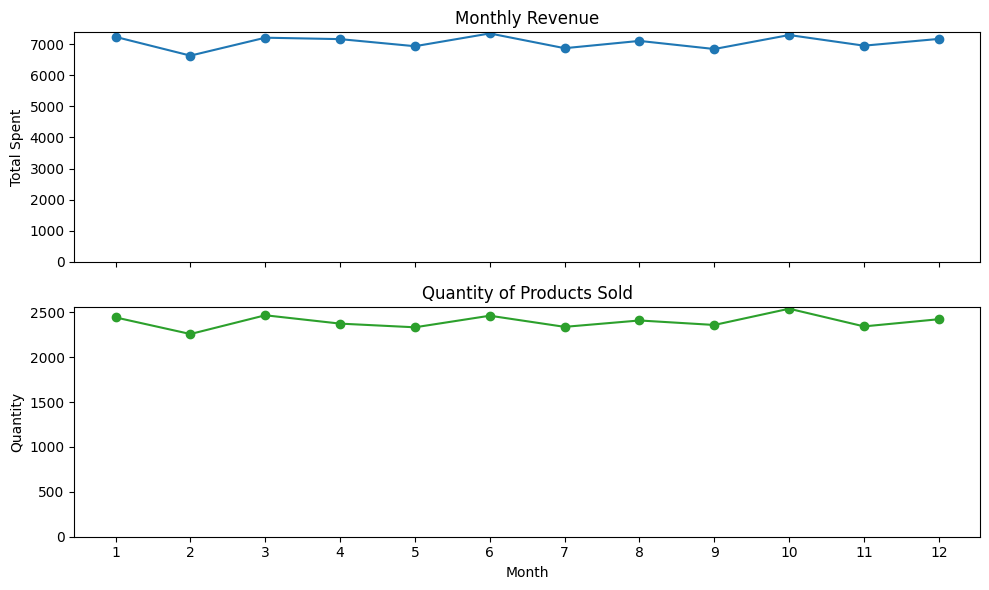

In [27]:
# ¿Se tienen la misma cantidad de venta todos los meses?
monthly_spent = cafe_sales.groupby("Month")["Total Spent"].sum()
monthly_quantity = cafe_sales.groupby("Month")["Quantity"].sum()
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Gráfica de ingreso
axes[0].plot(monthly_spent.index, monthly_spent.values, marker="o", color="tab:blue")
axes[0].set_title("Monthly Revenue")
axes[0].set_ylabel("Total Spent")
axes[0].set_ylim(0)  # eje y inicia en 0

# Gráfica de cantidad
axes[1].plot(monthly_quantity.index, monthly_quantity.values, marker="o", color="tab:green")
axes[1].set_title("Quantity of Products Sold")
axes[1].set_ylabel("Quantity")
axes[1].set_ylim(0)  # eje y inicia en 0
plt.xlabel("Month")
axes[1].set_xticks(monthly_spent.index)
plt.tight_layout()
plt.show()


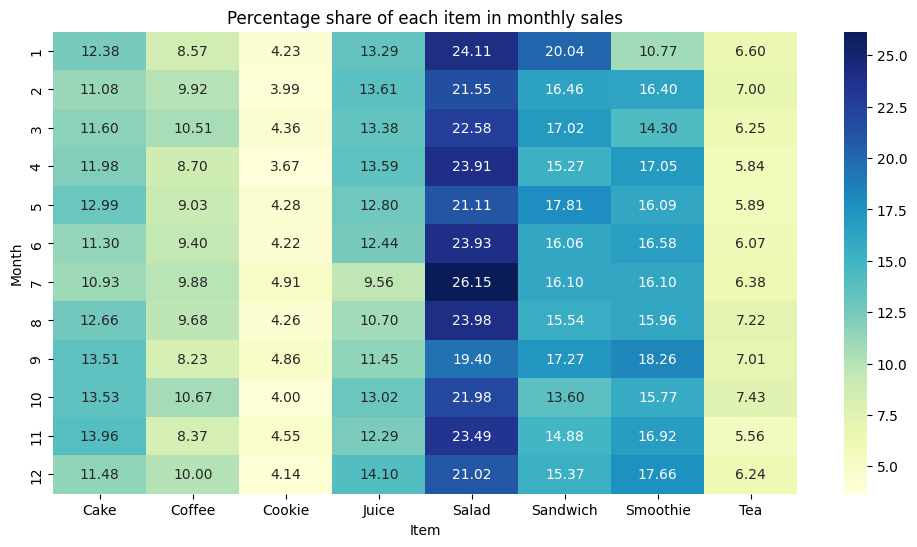

In [33]:
# Ahora que vemos que es estable, podemos ver qué parte aportan por mes.
Sales_by_month = cafe_sales.pivot_table(values="Total Spent", index="Month",columns="Item",aggfunc="sum")
# Ahora vamos a verlo en porcentajes de contribución a las ventas del mes
Sales_by_month_pct = Sales_by_month.div(Sales_by_month.sum(axis=1), axis=0) * 100
#print(Sales_by_month_pct) 
# Le agregamos colores para que sea más visible cuáles aportan más y cuáles no
plt.figure(figsize=(12,6)) 
sns.heatmap(Sales_by_month_pct, annot=True, fmt=".2f", cmap="YlGnBu") 
plt.title("Percentage share of each item in monthly sales") 
plt.ylabel("Month") 
plt.xlabel("Item") 
plt.show()

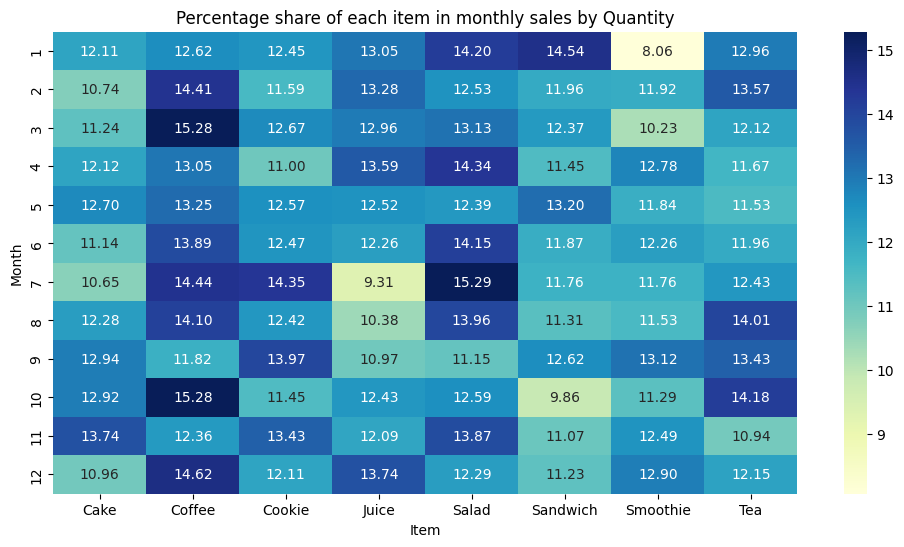

In [35]:
# Ahora que vemos que es estable, podemos ver qué parte aportan por mes.
Quantity_by_month = cafe_sales.pivot_table(values="Quantity", index="Month",columns="Item",aggfunc="sum")
# Ahora vamos a verlo en porcentajes de contribución a las ventas del mes
Quantity_by_month_pct = Quantity_by_month.div(Quantity_by_month.sum(axis=1), axis=0) * 100
# Le agregamos colores para que sea más visible cuáles aportan más y cuáles no
plt.figure(figsize=(12,6)) 
sns.heatmap(Quantity_by_month_pct, annot=True, fmt=".2f", cmap="YlGnBu") 
plt.title("Percentage share of each item in monthly sales by Quantity") 
plt.ylabel("Month") 
plt.xlabel("Item") 
plt.show()